In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('~/plots/paper.mplstyle')

In [2]:
# Analytical models with space weather relevance

def jelinek_bs(y, pdyn, r0=15.02, l=1.17, e=6.55):
    """
    Bow shock model from Jelinek et al 2012. Assumes GSE Z=0 RE.

    Parameters:
    -----------
    -    y (float): GSE Y coordinate (RE)
    -    pdyn (float): Solar wind dynamic pressure (nPa)
    -    r0 (float): Bow shock average standoff distance tuning parameter (RE)
    -    l (float): Lambda tuning parameter
    -    e (float): Epsilon tuning parameter
    Returns:
    --------
    -    bs_x (float): GSE X position of bow shock (RE)
    """
    bs_x = r0 * (pdyn ** (-1 / e)) - (y**2) * (l**2) / (4 * r0 * (pdyn ** (-1 / e)))
    return bs_x

def shue_mp(theta, pdyn, bz):
    """
    Magnetopause model from Shue et al 1998. Assumes GSE Z=0 RE.

    Parameters:
    -----------
    -    theta (float): Polar angle position of desired MP location (radians)
    -    pdyn (float): Solar wind dynamic pressure (nPa)
    -    bz (float): IMF Bz (nT)
    Returns:
    -    rmp (float): Magnetopause radial distance to Earth (RE)
    """
    r0 = (10.22 + 1.29 * np.tanh(0.184 * (bz + 8.14))) * (pdyn ** (-1 / 6.6))
    a1 = (0.58 - 0.007 * bz) * (1 + 0.024 * np.log(pdyn))
    rmp = r0 * (2 / (1 + np.cos(theta))) ** a1
    return rmp

def pdyn(n, vx, vy, vz):
    '''
    Returns solar wind dynamic pressure in nPa from solar wind density (n) in cm^-3 and velocity (vi) in km/s.
    Same as used in OMNI (see https://omniweb.gsfc.nasa.gov/html/HROdocum.html#G)

    Parameters
    ----------
    n : float, array-like
        Solar wind plasma density in cm^-3
    vx : float, array-like
        Solar wind GSE X velocity in km/s
    vy : float, array-like
        Solar wind GSE Y velocity in km/s
    vz : float, array-like
        Solar wind GSE Z velocity in km/s

    Returns
    -------
    pdyn : float, array-like
        Solar wind dynamic pressure in nPa.
    '''
    return 2e-6 * n * (vx**2 + vy**2 + vz**2)

def EKL(vx, vy, vz, by, bz):
    '''
    Returns Kan-Lee electric field in mV/m given solar wind V and B.
    Could work for magnetosheath, but the Kan-Lee E field was not developed for the sheath so it is not recommended.

    Parameters
    ----------
    vx : float, array-like
        Solar wind GSE X velocity in km/s
    vy : float, array-like
        Solar wind GSE Y velocity in km/s
    vz : float, array-like
        Solar wind GSE Z velocity in km/s
    by : float, array-like
        Interplanetary magnetic field GSM Y component in nT
    bz : float, array-like
        Interplanetary magnetic field GSM Z component in nT

    Returns
    -------
    ekl : float, array-like
        Kan-Lee electric field in mV/m
    '''
    ekl = 0.001*np.sqrt(vx**2+vy**2+vz**2)*np.sqrt(by**2+bz**2)*(np.sin(np.arctan2(by, bz)/2))**2
    return ekl

def EKL_err(vx, vx_sig, vy, vy_sig, vz, vz_sig, by, by_sig, bz, bz_sig):
    '''
    Returns error in Kan-Lee electric field in mV/m given solar wind V and B and 1sigma uncertainties.
    Could work for magnetosheath, but the Kan-Lee E field was not developed for the sheath so it is not recommended.

    Parameters
    ----------
    vx : float, array-like
        Solar wind GSE X velocity in km/s
    vx_sig : float, array-like
        Solar wind GSE X velocity 1sigma error in km/s
    vy : float, array-like
        Solar wind GSE Y velocity in km/s
    vy_sig : float, array-like
        Solar wind GSE Y velocity 1sigma error in km/s
    vz : float, array-like
        Solar wind GSE Z velocity in km/s
    vz_sig : float, array-like
        Solar wind GSE Z velocity 1sigma error in km/s
    by : float, array-like
        Interplanetary magnetic field GSM Y component in nT
    by_sig : float, array-like
        Interplanetary magnetic field GSM Y component 1sigma error in nT
    bz : float, array-like
        Interplanetary magnetic field GSM Z component in nT
    bz_sig : float, array-like
        Interplanetary magnetic field GSM Z component 1sigma error in nT

    Returns
    -------
    ekl_err : float, array-like
        Kan-Lee electric field 1sigma error in mV/m
    '''
    dekl_dvx = 0.001*vx*((vx**2+vy**2+vz**2)**(-1/2))*np.sqrt(by**2+bz**2)*(np.sin(np.arctan2(by, bz)/2))**2
    dekl_dvy = 0.001*vy*((vx**2+vy**2+vz**2)**(-1/2))*np.sqrt(by**2+bz**2)*(np.sin(np.arctan2(by, bz)/2))**2
    dekl_dvz = 0.001*vz*((vx**2+vy**2+vz**2)**(-1/2))*np.sqrt(by**2+bz**2)*(np.sin(np.arctan2(by, bz)/2))**2
    dekl_dby = 0.001*np.sqrt(vx**2+vy**2+vz**2)*by*((by**2+bz**2)**(1/2))*(np.sin(np.arctan2(by, bz)/2))**2 + 0.001*np.sqrt(vx**2+vy**2+vz**2)*np.sqrt(by**2+bz**2)*by/(2*np.sqrt((by/bz)**2 + 1)*(by**2 + bz**2))
    dekl_dbz = 0.001*np.sqrt(vx**2+vy**2+vz**2)*bz*((by**2+bz**2)**(1/2))*(np.sin(np.arctan2(by, bz)/2))**2 - 0.001*np.sqrt(vx**2+vy**2+vz**2)*np.sqrt(by**2+bz**2)*(by**2)*bz*np.sqrt((by/bz)**2 + 1)/(2*(by**2 + bz**2)**2)

    ekl_err = np.sqrt((dekl_dvx*vx_sig)**2 + (dekl_dvy*vy_sig)**2 + (dekl_dvz*vz_sig)**2 + (dekl_dby*by_sig)**2 + (dekl_dbz*bz_sig)**2)
    return ekl_err

def EMR(vx, bz, by = None, rect = np.nan):
    '''
    Returns rectified Y component of motional electric field in a magnetized plasma.

    Parameters
    ----------
    vx : float, array-like
        Plasma X velocity in km/s
    bz : float, array-like
        Magnetic field Z component in nT
    by : float, array-like, optional
        Magnetic field Y component in nT. If specified, use the tangential magnetic field
        bt=sqrt(by^2 + bz^2) instead of bz. bt is still rectified for northward bz. Default None.
    rect : float, optional
        Value negative E fields are rectified to. Default NaN

    Returns
    -------
    emr : float, array-like
        Motional electric field Y component in mV/m
    '''
    if by is not None:
        emr = 0.001*np.abs(vx*np.where(bz <= 0, np.sqrt(bz**2 + by**2), rect))
    else:
        emr = 0.001*np.abs(vx*np.where(bz <= 0, bz, rect))
    return emr

def EMR_err(vx, vx_sig, bz, bz_sig, by = None, by_sig = None, rect = np.nan):
    '''
    Returns error in rectified Y component of motional electric field in a magnetized plasma.

    Parameters
    ----------
    vx : float, array-like
        Plasma X velocity in km/s
    vx_sig : float, array-like
        1sigma error in plasma X velocity in km/s
    bz : float, array-like
        Magnetic field Z component in nT
    bz_sig : float, array-like
        1sigma error in magnetic field Z component in nT
    by : float, array-like, optional
        Magnetic field Y component in nT. If specified, use the tangential magnetic field
        bt=sqrt(by^2 + bz^2) instead of bz AND require by_sig. bt is still rectified for northward bz. 
        Default None.
    by : float, array-like, optional
        1sigma error in magnetic field Y component in nT. If specified, use the tangential magnetic 
        field bt=sqrt(by^2 + bz^2) instead of bz AND require by. bt is still rectified for northward 
        bz. Default None.
    rect : float
        Value negative E fields are rectified to. Default NaN

    Returns
    -------
    emr_std : float, array-like
        1sigma error in motional electric field Y component in mV/m
    '''
    if (by is not None)&(by_sig is not None):
        bt = np.sqrt(by**2 + bz**2)
        bt_sig = (by+bz)/np.sqrt(by**2 + bz**2)
        emr_std = np.sqrt(
            (0.001*np.abs(vx_sig*np.where(bz <= 0, bt, rect)))**2 + #dEMR/dvx term
            (0.001*np.abs(vx*np.where(bz <= 0, bt_sig, rect)))**2 #dEMR/dbz term
        )
    else:
        emr_std = np.sqrt(
            (0.001*np.abs(vx_sig*np.where(bz <= 0, bz, rect)))**2 + #dEMR/dvx term
            (0.001*np.abs(vx*np.where(bz <= 0, bz_sig, rect)))**2 #dEMR/dbz term
        )
    return emr_std

def tm03(n_sw, vx_sw, vy_sw, vz_sw, bz_sw, x, y, z, cut_mp = True, cut_pos = True):
    """
    Magnetotail model from Tsyganenko and Mukai, 2003 (DOI 10.1029/2002JA009707)
    
    n and t are both for ions
    """
    r_norm = np.sqrt(x**2 + y**2)/10.0 #TODO: Figure out if that -1 is necessary
    phi = np.arctan2(y , -1*x)
    n_norm = n_sw / 10.0
    v_sw = np.sqrt(vx_sw**2 + vy_sw**2 + vz_sw**2)
    v_norm = v_sw / 500.0
    bn_norm = np.where(bz_sw > 0, bz_sw/5.0, 0)
    bs_norm = np.where(bz_sw < 0, -1*bz_sw/5.0, 0)
    # Constants from TM03 Table 1
    a_n = np.asarray([-0.159, 0.608, 0.5055, 0.0796, 0.2746, 0.0361, -0.0342, -0.7933, 1.162, 0.4756, 0.7117])
    a_t = np.asarray([1.67870, -0.16057, 1.66874, 4.81969, 2.85451, -0.60195, -0.83629, -2.49105, 0.25679, 0.22486, 0.18870, -0.44579, -0.03306, -0.02412, -2.68930, 1.22152])
    
    n = (a_n[0] + a_n[1] * (n_norm**a_n[9]) + a_n[2] * bn_norm + a_n[3] * v_norm * bs_norm) * (r_norm ** a_n[7]) + (a_n[4] * (n_norm**a_n[10]) + a_n[5] * bn_norm + a_n[6] * v_norm * bs_norm) * (r_norm ** a_n[8]) * (np.sin(phi) ** 2)
    n[n < np.nextafter(0, 1)] = np.nan
    t = (a_t[0]*v_norm + a_t[1]*bn_norm + a_t[2]*bs_norm + a_t[3]*np.exp(-(a_t[8]*v_norm**a_t[14] + a_t[9]*bn_norm + a_t[10]*bs_norm)*(r_norm-1)) + (a_t[4]*v_norm + a_t[5]*bn_norm + a_t[6]*bs_norm + a_t[7]*np.exp(-(a_t[11]*v_norm**a_t[15] + a_t[12]*bn_norm + a_t[13]*bs_norm)*(r_norm-1))) * (np.sin(phi)**2))
    t[t < np.nextafter(0, 1)] = np.nan

    # if cut_mp: #Cut points outside a model magnetopause (Shue et al. 1998)
    #     rm = shue98(n_sw, vx_sw, vy_sw, vz_sw, bz_sw, x, y, z)
    #     r = np.sqrt(x**2 + y**2 + z**2)
    #     n[r > rm] = np.nan
    #     t[r > rm] = np.nan
    if cut_pos: #Cut points too close to Earth
        n[r_norm < 10.0/10.0] = np.nan
        n[np.abs(phi) > np.pi/2] = np.nan
        t[r_norm < 10.0/10.0] = np.nan
        t[np.abs(phi) > np.pi/2] = np.nan
    return n, t

In [3]:
# Load storm-time PRIME and OMNI data
trange = ['2013-03-17 00:00:00', '2013-03-18 00:00:00']
sw_data = pd.read_hdf("~/data/prime/prime_cache.h5", key = "prime_v1_outer_omni_1min")
sw_data = sw_data.loc[
    (sw_data["Epoch"] >= pd.to_datetime(trange[0], utc = True))&
    (sw_data["Epoch"] <= pd.to_datetime(trange[1], utc = True)),
    :
]

# Calculate the dynamic pressure at mean, low, and high driving cases
sw_data["Pdyn"] = pdyn(sw_data["Ne"], sw_data['V_GSE_0'], sw_data['V_GSE_1'], sw_data['V_GSE_2'])
sw_data["Pdyn_high"] = pdyn(sw_data["Ne"] + sw_data["Ne_sig"], sw_data['V_GSE_0'] - sw_data["V_GSE_sig_0"], sw_data['V_GSE_1'], sw_data['V_GSE_2'])
sw_data["Pdyn_low"] = pdyn(sw_data["Ne"] - sw_data["Ne_sig"], sw_data['V_GSE_0'] + sw_data["V_GSE_sig_0"], sw_data['V_GSE_1'], sw_data['V_GSE_2'])
sw_data["Pdyn_omni"]= pdyn(sw_data["proton_density"], sw_data['Vx'], sw_data['Vy'], sw_data['Vz'])

: 

/glade/derecho/scratch/cobrien/tmp/ipykernel_80461/3173510193.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=45, ha = "right", rotation_mode='anchor')


Text(0, 0.5, '$v_{X}$ (km/s)')

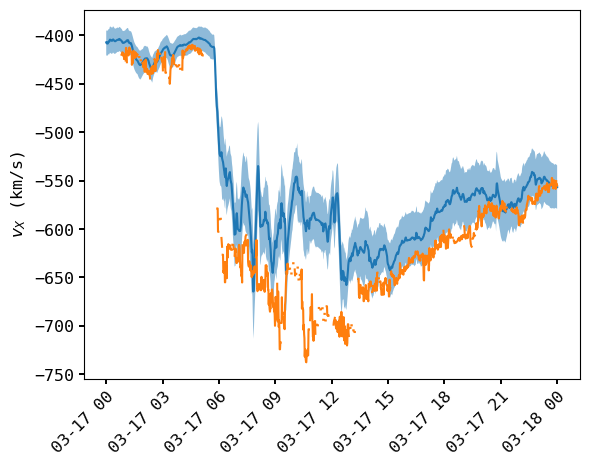

In [ ]:
plt.plot(sw_data["Epoch"], sw_data["V_GSE_0"], label = "PRIME")
plt.plot(sw_data["Epoch"], sw_data["Vx"], label = "OMNI")
plt.fill_between(sw_data["Epoch"], sw_data["V_GSE_0"] - sw_data["V_GSE_sig_0"] , sw_data["V_GSE_0"] + sw_data["V_GSE_sig_0"], alpha = 0.5)
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=45, ha = "right", rotation_mode='anchor')
plt.ylabel(f"$v_{{X}}$ (km/s)")

/glade/derecho/scratch/cobrien/tmp/ipykernel_80461/4075042662.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=45, ha = "right", rotation_mode='anchor')


Text(0, 0.5, '$n_{i}$ ($cm^{-3}$)')

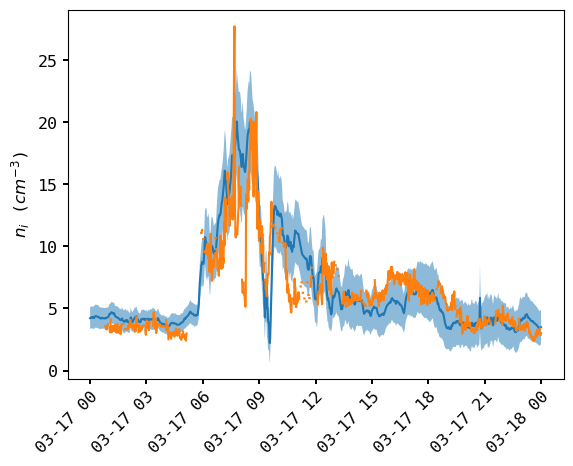

In [ ]:
plt.plot(sw_data["Epoch"], sw_data["Ne"], label = "PRIME")
plt.plot(sw_data["Epoch"], sw_data["proton_density"], label = "OMNI")
plt.fill_between(sw_data["Epoch"], sw_data["Ne"] - sw_data["Ne_sig"] , sw_data["Ne"] + sw_data["Ne_sig"], alpha = 0.5)
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=45, ha = "right", rotation_mode='anchor')
plt.ylabel(f"$n_{{i}}$ ($cm^{{-3}}$)")

/glade/derecho/scratch/cobrien/tmp/ipykernel_80461/4092099726.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=45, ha = "right", rotation_mode='anchor')


Text(0, 0.5, '$P_{dyn}$ (nPa)')

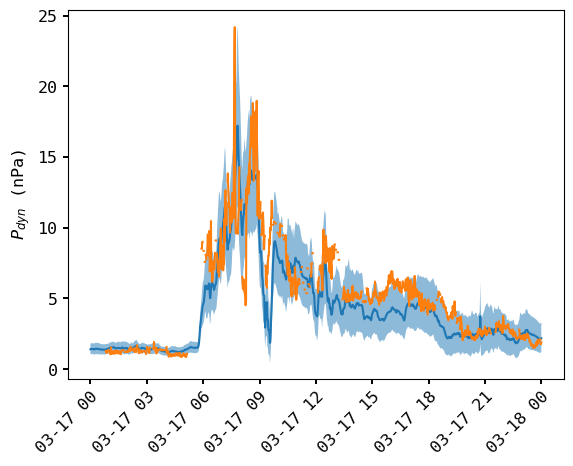

In [ ]:
plt.plot(sw_data["Epoch"], sw_data["Pdyn"], label = "PRIME")
plt.plot(sw_data["Epoch"], sw_data["Pdyn_omni"], label = "OMNI")
plt.fill_between(sw_data["Epoch"], sw_data["Pdyn_low"] , sw_data["Pdyn_high"], alpha = 0.5)
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=45, ha = "right", rotation_mode='anchor')
plt.ylabel(f"$P_{{dyn}}$ (nPa)")

In [ ]:
bounds = [-35, 35]
theta = np.linspace(-9*np.pi/10, 9*np.pi/10, 200) # Grid of angles to calculate the magnetopause on
y = np.linspace(bounds[0], bounds[1], 200) # Grid of y positions to calculate the bow shock on

for i, idx in enumerate(sw_data.index):
    MP_r = shue_mp(theta, sw_data.loc[idx, 'Pdyn'], sw_data.loc[idx, "B_GSM_2"])
    MP_r_in = shue_mp(theta, sw_data.loc[idx, 'Pdyn_high'], sw_data.loc[idx, "B_GSM_2"] - sw_data.loc[idx, "B_GSM_sig_2"])
    MP_r_out = shue_mp(theta, sw_data.loc[idx, 'Pdyn_low'], sw_data.loc[idx, "B_GSM_2"] + sw_data.loc[idx, "B_GSM_sig_2"])
    MP_r_omni = shue_mp(theta, sw_data.loc[idx, 'Pdyn_omni'], sw_data.loc[idx, "BZ_GSE"])
    BS_x = jelinek_bs(y, sw_data.loc[idx, 'Pdyn'])
    BS_x_in = jelinek_bs(y, sw_data.loc[idx, 'Pdyn_high'])
    BS_x_out = jelinek_bs(y, sw_data.loc[idx, 'Pdyn_low'])
    BS_x_omni = jelinek_bs(y, sw_data.loc[idx, 'Pdyn_omni'])
    
    fig, ax = plt.subplots(1,1, figsize = (8, 8))
    
    plt.plot(MP_r * np.cos(theta), MP_r * np.sin(theta), color = 'k', label = "Shue '98 Magnetopause")
    plt.plot(MP_r_out * np.cos(theta), MP_r_out * np.sin(theta), color = 'k', alpha = 0.5, label = "Shue '98 Magnetopause (Outer)")
    plt.plot(MP_r_in * np.cos(theta), MP_r_in * np.sin(theta), color = 'k', alpha = 0.5, label = "Shue '98 Magnetopause (Inner)")
    plt.plot(MP_r_omni * np.cos(theta), MP_r_omni * np.sin(theta), color = 'k', alpha = 0.5, ls = ':', label = "Shue '98 Magnetopause (OMNI)")
    plt.plot(BS_x, y, color = 'r', label = "Jelinek '12 Bow Shock")
    plt.plot(BS_x_out, y, color = 'r', alpha = 0.5, label = "Jelinek '12 Bow Shock (Outer)")
    plt.plot(BS_x_in, y, color = 'r', alpha = 0.5, label = "Jelinek '12 Bow Shock (Inner)")
    plt.plot(BS_x_omni, y, color = 'r', alpha = 0.5, ls = ':', label = "Jelinek '12 Bow Shock (OMNI)")

    plt.xlim(bounds[1], bounds[0])
    plt.ylim(bounds[0], bounds[1])
    plt.gca().set_aspect('equal')
    plt.xlabel(r"X GSM $R_{E}$")
    plt.ylabel(r"Y GSM $R_{E}$")
    plt.text(bounds[1]*0.95, bounds[0]*0.85, 
            s = f"$P_{{dyn}}$: {sw_data.loc[idx, 'Pdyn']:.2f}$\pm${(sw_data.loc[idx, 'Pdyn_high'] - sw_data.loc[idx, 'Pdyn_low'])/2:.2f} nPa")
    plt.text(bounds[1]*0.95, bounds[0]*0.95, 
            s = f"$B_{{Z}}$: {sw_data.loc[idx, 'B_GSM_2']:.2f}$\pm${sw_data.loc[idx, 'B_GSM_2']:.2f} nT")
    plt.title(sw_data.loc[idx, 'Epoch'])
    plt.savefig(f"/glade/u/home/cobrien/plots/doctor-patient-day/mpvid/vid.{i:04}.png")
    plt.close()
    print(f"Completed {i} of {len(sw_data.index)}", end = '\r')

: 

In [ ]:
bins = np.arange(5, 13, 0.5)

plt.hist(shue_mp(0, sw_data['Pdyn'], sw_data['B_GSM_2']), bins = bins, alpha = 0.3, color = "tab:blue", label = 'Mean Driving')
plt.hist(shue_mp(0, sw_data['Pdyn_low'], sw_data['B_GSM_2'] + sw_data['B_GSM_sig_2']), bins = bins, alpha = 0.3, color = "tab:orange", label = "Low Driving")
plt.hist(shue_mp(0, sw_data['Pdyn_high'], sw_data['B_GSM_2'] - sw_data['B_GSM_sig_2']), bins = bins, alpha = 0.3, color = "tab:green", label = "High Driving")

plt.legend(frameon = False)
plt.xlabel(f"Subsolar Magnetopause Distance ($R_E$)")

plt.gca().axvline(shue_mp(0, sw_data['Pdyn'], sw_data['B_GSM_2']).mean(), color = "tab:blue", ls = '--')
plt.gca().axvline(shue_mp(0, sw_data['Pdyn_low'], sw_data['B_GSM_2'] + sw_data['B_GSM_sig_2']).mean(), color = "tab:orange", ls = '--')
plt.gca().axvline(shue_mp(0, sw_data['Pdyn_high'], sw_data['B_GSM_2'] - sw_data['B_GSM_sig_2']).mean(), color = "tab:green", ls = '--')

In [14]:
idx = 1686253
x_1d = np.arange(-30, -5, 0.5)
y_1d = np.arange(-12.5, 12.5, 0.5)
x_grid, y_grid = np.meshgrid(x_1d, y_1d)

n, t = tm03(sw_data.loc[idx, 'Ne'], sw_data.loc[idx, 'V_GSE_0'], sw_data.loc[idx, 'V_GSE_1'], sw_data.loc[idx, 'V_GSE_2'], sw_data.loc[idx, 'B_GSM_2'], x_grid, y_grid, 0)
n_high, t_high = tm03(sw_data.loc[idx, 'Ne'] + sw_data.loc[idx, 'Ne_sig'], sw_data.loc[idx, 'V_GSE_0'] - sw_data.loc[idx, 'V_GSE_sig_0'], sw_data.loc[idx, 'V_GSE_1'], sw_data.loc[idx, 'V_GSE_2'], sw_data.loc[idx, 'B_GSM_2'], x_grid, y_grid, 0)
n_low, t_low = tm03(sw_data.loc[idx, 'Ne'] - sw_data.loc[idx, 'Ne_sig'], sw_data.loc[idx, 'V_GSE_0'] + sw_data.loc[idx, 'V_GSE_sig_0'], sw_data.loc[idx, 'V_GSE_1'], sw_data.loc[idx, 'V_GSE_2'], sw_data.loc[idx, 'B_GSM_2'], x_grid, y_grid, 0)

In [ ]:
# idx = 1686253
x_1d = np.arange(-30, -5, 0.5)
y_1d = np.arange(-12.5, 12.5, 0.5)
x_grid, y_grid = np.meshgrid(x_1d, y_1d)

nmax = 0
for i, idx in enumerate(sw_data.index):
    n, t = tm03(sw_data.loc[idx, 'Ne'], sw_data.loc[idx, 'V_GSE_0'], sw_data.loc[idx, 'V_GSE_1'], sw_data.loc[idx, 'V_GSE_2'], sw_data.loc[idx, 'B_GSM_2'], x_grid, y_grid, 0)
    n_high, t_high = tm03(sw_data.loc[idx, 'Ne'] + sw_data.loc[idx, 'Ne_sig'], sw_data.loc[idx, 'V_GSE_0'] - sw_data.loc[idx, 'V_GSE_sig_0'], sw_data.loc[idx, 'V_GSE_1'], sw_data.loc[idx, 'V_GSE_2'], sw_data.loc[idx, 'B_GSM_2'], x_grid, y_grid, 0)
    n_low, t_low = tm03(sw_data.loc[idx, 'Ne'] - sw_data.loc[idx, 'Ne_sig'], sw_data.loc[idx, 'V_GSE_0'] + sw_data.loc[idx, 'V_GSE_sig_0'], sw_data.loc[idx, 'V_GSE_1'], sw_data.loc[idx, 'V_GSE_2'], sw_data.loc[idx, 'B_GSM_2'], x_grid, y_grid, 0)

    plt.subplots(1,1, figsize = (8,8))
    im = plt.imshow((n_high - n_low), extent = (x_1d[0], x_1d[-1], y_1d[0], y_1d[-1]), vmin = 0, vmax = 0.4)
    plt.xlabel(f"X GSM ($R_E$)")
    plt.ylabel(f"Y GSM ($R_E$)")
    plt.colorbar(im, label = f"$\Delta n_i$ ($cm^{{-3}}$)")
    plt.gca().set_aspect("equal")
    plt.title(f"TM03 Magnetotail Density Difference\n{sw_data.loc[idx, 'Epoch']}")

    plt.savefig(f"/glade/u/home/cobrien/plots/doctor-patient-day/tailvid/vid.{i:04}.png")
    plt.close()
    print(f"Completed {i} of {len(sw_data.index)}", end = '\r')

: 

(array([15781.   , 15781.125, 15781.25 , 15781.375, 15781.5  , 15781.625,
        15781.75 , 15781.875, 15782.   ]),
 [Text(15781.0, 0, '03-17 00'),
  Text(15781.125, 0, '03-17 03'),
  Text(15781.25, 0, '03-17 06'),
  Text(15781.375, 0, '03-17 09'),
  Text(15781.5, 0, '03-17 12'),
  Text(15781.625, 0, '03-17 15'),
  Text(15781.75, 0, '03-17 18'),
  Text(15781.875, 0, '03-17 21'),
  Text(15782.0, 0, '03-18 00')])

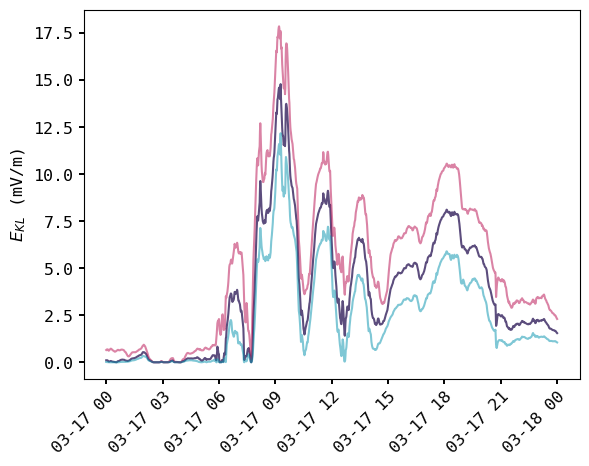

In [11]:
r = '#B7094C'
g = '#5C4D7D'
b = '#0091AD'

sw_data['EKL'] = EKL(sw_data['V_GSE_0'], sw_data['V_GSE_1'], sw_data['V_GSE_2'], sw_data['B_GSM_1'], sw_data['B_GSM_2'])
sw_data['EKL_high'] = EKL(sw_data['V_GSE_0'] - sw_data['V_GSE_sig_0'], sw_data['V_GSE_1'], sw_data['V_GSE_2'], sw_data['B_GSM_1'], sw_data['B_GSM_2'] - sw_data['B_GSM_sig_2'])
sw_data['EKL_low'] = EKL(sw_data['V_GSE_0'] + sw_data['V_GSE_sig_0'], sw_data['V_GSE_1'], sw_data['V_GSE_2'], sw_data['B_GSM_1'], sw_data['B_GSM_2'] + sw_data['B_GSM_sig_2'])
sw_data['EKL_omni'] = EKL(sw_data['Vx'], sw_data['Vy'], sw_data['Vz'], sw_data['BY_GSE'], sw_data['BZ_GSE'])

plt.plot(sw_data['Epoch'], sw_data['EKL'], label = 'Mean', color = g)
plt.plot(sw_data['Epoch'], sw_data['EKL_high'], label = 'High', color = r, alpha = 0.5)
plt.plot(sw_data['Epoch'], sw_data['EKL_low'], label = 'Low', color = b, alpha = 0.5)
# plt.plot(sw_data['Epoch'], sw_data['EKL_omni'], label = 'OMNI', color = 'k', alpha = 0.5)
plt.ylabel(f"$E_{{KL}}$ (mV/m)")
plt.xticks(label = plt.gca().get_xticklabels(), rotation=45, ha = "right", rotation_mode='anchor')